Load Tagesschau first due to different date format

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent, *cwd.parents):
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"

In [2]:
ts_path = RAW_DIR / "tagesschau_clean.csv"
if not ts_path.exists():
    raise FileNotFoundError(f"Missing file: {ts_path}")

df_ts = pd.read_csv(ts_path)
print(f"tagesschau   {df_ts.shape} <- {ts_path}")

# Parse date column to match overall_df format
df_ts["Date"] = pd.to_datetime(df_ts["Date"], errors="coerce", utc=True)\
                   .dt.tz_convert("Europe/Berlin")\
                   .dt.tz_localize(None)\
                   .dt.normalize()

print(df_ts["Date"].dtype)
df_ts.head()

tagesschau   (6320, 4) <- /Users/gretawette/Documents/Thesis/data/raw/tagesschau_clean.csv
datetime64[us]


,Date,Title,Text,source
0,2025-09-01,Deutschland holt zehn afghanische Familien aus...,Zehn afghanische Familien dürfen aus Pakistan ...,Tagesschau
1,2025-10-01,Afghanistan ist wieder online,Handys und Internet funktionieren in Afghanist...,Tagesschau
2,2025-10-24,Äthiopien suspendiert Deutsche-Welle-Journalisten,Die Deutsche Welle darf vorerst nicht mehr dir...,Tagesschau
3,2025-10-02,Mindestens 30 Tote bei Einsturz von Baugerüst,Viele Menschen befanden sich in der Kirche der...,Tagesschau
4,2025-09-30,Brechen afrikanische Exporte in die USA ein?,Seit Jahrzehnten verkaufen mehr als die Hälfte...,Tagesschau


In [3]:
df_ts['Date'].max()

Timestamp('2026-01-31 00:00:00')

In [4]:
# Format Date as DD-MM-YYYY (no time)
df_ts["Date"] = pd.to_datetime(df_ts["Date"], errors="coerce").dt.strftime("%d-%m-%Y")

df_ts[["Date"]].head()

,Date
0,01-09-2025
1,01-10-2025
2,24-10-2025
3,02-10-2025
4,30-09-2025


In [5]:
# Convert Date from string format (DD-MM-YYYY) to datetime64[ns]
df_ts["Date"] = pd.to_datetime(df_ts["Date"], format="%d-%m-%Y", errors="coerce")

df_ts[["Date"]].dtypes

Date    datetime64[us]
dtype: object

load all other outlets

In [6]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go


def resolve_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, cwd.parent, *cwd.parents):
        if (candidate / "data" / "raw").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing data/raw")


PROJECT_ROOT = resolve_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"

file_map = {
    "antispiegel": "antispiegel_clean.csv",
    "compact": "compact_clean.csv",
    "nius": "nius_clean.csv",
    "rt_de": "rt_de_clean.csv",
    # "tagesschau": "tagesschau_clean.csv",
    "tichys": "tichys_clean.csv",
    "dkurier": "dkurier_clean.csv",
}

datasets = {}
for name, filename in file_map.items():
    path = RAW_DIR / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing file for {name}: {path}")
    datasets[name] = pd.read_csv(path)
    print(f"{name:<12} {datasets[name].shape} <- {path}")

overall_df = pd.concat(datasets.values(), ignore_index=True)
print("overall_df  ", overall_df.shape)


antispiegel  (589, 4) <- /Users/gretawette/Documents/Thesis/data/raw/antispiegel_clean.csv
compact      (1564, 4) <- /Users/gretawette/Documents/Thesis/data/raw/compact_clean.csv
nius         (3269, 4) <- /Users/gretawette/Documents/Thesis/data/raw/nius_clean.csv
rt_de        (4560, 4) <- /Users/gretawette/Documents/Thesis/data/raw/rt_de_clean.csv
tichys       (2946, 4) <- /Users/gretawette/Documents/Thesis/data/raw/tichys_clean.csv
dkurier      (1484, 4) <- /Users/gretawette/Documents/Thesis/data/raw/dkurier_clean.csv
overall_df   (14412, 4)


In [7]:
overall_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14412 entries, 0 to 14411
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    14412 non-null  str  
 1   Title   14412 non-null  str  
 2   Text    14411 non-null  str  
 3   source  14412 non-null  str  
dtypes: str(4)
memory usage: 450.5 KB


In [8]:
overall_df['source'].value_counts()

source
RT_de                4560
Nius                 3269
Tichys_Einblick      2946
Compact              1564
Deutschlandkurier    1484
Antispiegel           589
Name: count, dtype: int64

Change dtype of Date to match tagesschau

In [9]:
print(overall_df["Date"].dtype)    

str


In [10]:
overall_df["Date"] = pd.to_datetime(overall_df["Date"], errors="coerce", utc=True)\
                        .dt.tz_localize(None)\
                        .dt.normalize()


In [11]:
print(overall_df["Date"].dtype)  

datetime64[us]


merge Tagesschau and rest

In [12]:
# Concatenate existing combined dataframe with Tagesschau dataframe
overall_df = pd.concat([overall_df, df_ts], ignore_index=True)

# Quick check
print("overall_df shape:", overall_df.shape)
overall_df["source"].value_counts()

overall_df shape: (20732, 4)


source
Tagesschau           6320
RT_de                4560
Nius                 3269
Tichys_Einblick      2946
Compact              1564
Deutschlandkurier    1484
Antispiegel           589
Name: count, dtype: int64

In [13]:
# NaN count in Date column
overall_df["Date"].isna().sum()

np.int64(0)

In [14]:
# # Convert Date to datetime in the combined dataframe
# overall_df["Date"] = pd.to_datetime(overall_df["Date"], errors="coerce")

# overall_df["Date"].dtype

In [15]:
# Add a unique ID column for each row in overall_df
overall_df = overall_df.reset_index(drop=True)
overall_df["row_id"] = overall_df.index + 1

# Optional quick check
print("Unique IDs:", overall_df["row_id"].is_unique)
overall_df[["row_id", "Date", "Title"]].head()

Unique IDs: True


,row_id,Date,Title
0,1,2025-08-01,Bereitet der Westen die Entmachtung oder sogar...
1,2,2025-08-01,EU-Kommission hat Textnachrichten zum Kauf der...
2,3,2025-08-01,Wahlkommission rechtfertigt Einmischung der EU...
3,4,2025-08-02,Fordert Russland wirklich die Vernichtung alle...
4,5,2025-08-02,Der Spiegel macht mal wieder Berichterstattung...


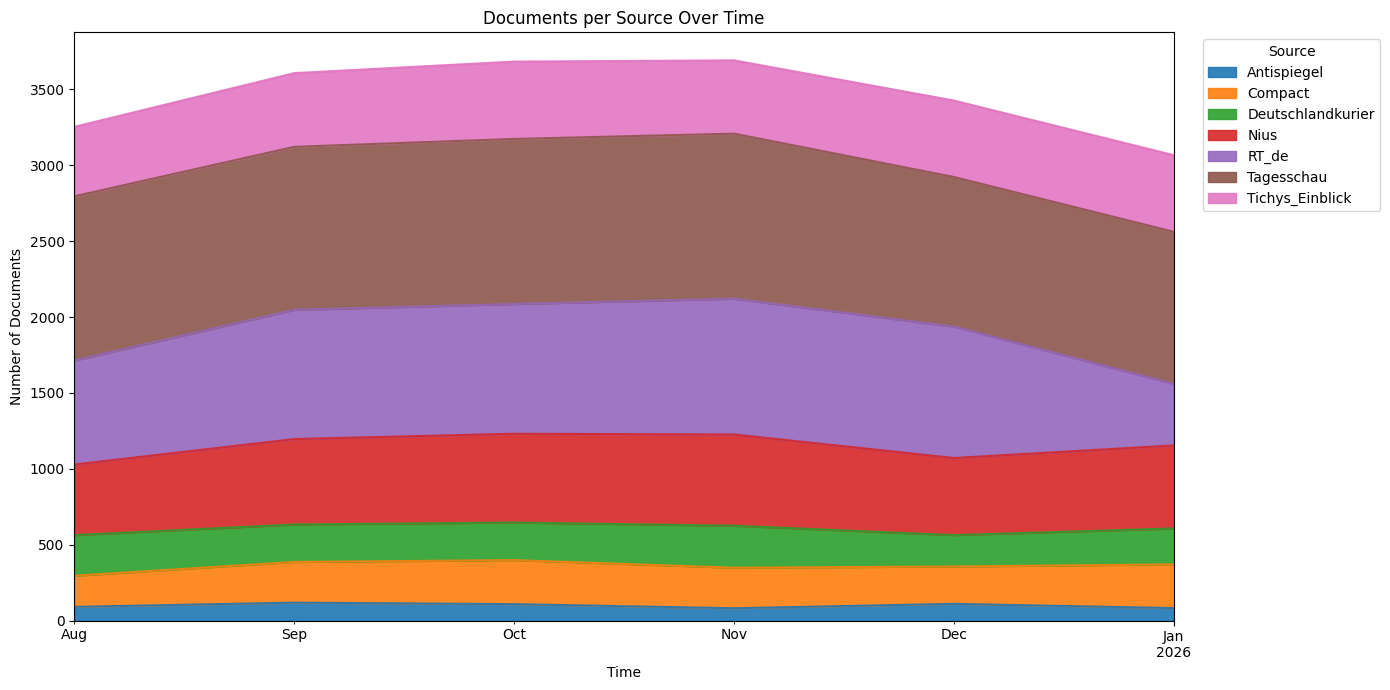

source,Antispiegel,Compact,Deutschlandkurier,Nius,RT_de,Tagesschau,Tichys_Einblick
period,,,,,,,
2025-08-01,90,205,268,465,686,1082,458
2025-09-01,118,268,247,563,852,1074,486
2025-10-01,108,290,248,585,855,1088,510
2025-11-01,81,267,277,601,895,1088,483
2025-12-01,110,246,207,508,866,986,504


In [16]:
import matplotlib.pyplot as plt

# Assumes you already have `overall_df` with columns: Date, source
df_plot = overall_df.copy()

# Parse date and keep valid rows
df_plot["Date"] = pd.to_datetime(df_plot["Date"], errors="coerce", utc=True).dt.tz_localize(None)
df_plot = df_plot.dropna(subset=["Date", "source"])

# Choose granularity: "D" (day), "W" (week), "M" (month)
freq = "M"

# Count docs per source over time
count_df = (
    df_plot
    .assign(period=df_plot["Date"].dt.to_period(freq).dt.to_timestamp())
    .groupby(["period", "source"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

# Plot stacked area chart
ax = count_df.plot.area(figsize=(14, 7), alpha=0.9)
ax.set_title("Documents per Source Over Time")
ax.set_xlabel("Time")
ax.set_ylabel("Number of Documents")
ax.legend(title="Source", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

count_df.head()


In [17]:
tmp = overall_df.copy()

# robust parse for mixed timezone formats (important for Tagesschau)
tmp["Date_parsed"] = pd.to_datetime(tmp["Date"], errors="coerce", utc=True)

qc = (
    tmp.groupby("source", dropna=False)
       .agg(
           rows=("Date", "size"),
           parsed_ok=("Date_parsed", lambda s: s.notna().sum()),
           parsed_na=("Date_parsed", lambda s: s.isna().sum()),
           parse_rate=("Date_parsed", lambda s: s.notna().mean()),
           min_date=("Date_parsed", "min"),
           max_date=("Date_parsed", "max"),
       )
       .sort_values("rows", ascending=False)
)

display(qc)


,rows,parsed_ok,parsed_na,parse_rate,min_date,max_date
source,,,,,,
Tagesschau,6320,6320,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00
RT_de,4560,4560,0,1.0,2025-08-01 00:00:00+00:00,2026-01-19 00:00:00+00:00
Nius,3269,3269,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00
Tichys_Einblick,2946,2946,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00
Compact,1564,1564,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00
Deutschlandkurier,1484,1484,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00
Antispiegel,589,589,0,1.0,2025-08-01 00:00:00+00:00,2026-01-31 00:00:00+00:00


In [18]:
display(
    tmp.loc[tmp["source"].str.contains("tagesschau", case=False, na=False),
            ["source", "Date", "Date_parsed"]]
       .head(20)
)


,source,Date,Date_parsed
14412,Tagesschau,2025-09-01,2025-09-01 00:00:00+00:00
14413,Tagesschau,2025-10-01,2025-10-01 00:00:00+00:00
14414,Tagesschau,2025-10-24,2025-10-24 00:00:00+00:00
14415,Tagesschau,2025-10-02,2025-10-02 00:00:00+00:00
14416,Tagesschau,2025-09-30,2025-09-30 00:00:00+00:00
14417,Tagesschau,2025-09-22,2025-09-22 00:00:00+00:00
14418,Tagesschau,2025-08-29,2025-08-29 00:00:00+00:00
14419,Tagesschau,2025-10-22,2025-10-22 00:00:00+00:00
14420,Tagesschau,2025-08-26,2025-08-26 00:00:00+00:00
14421,Tagesschau,2025-08-09,2025-08-09 00:00:00+00:00


In [19]:
# 1) Filter mask for Tagesschau rows
mask_ts = overall_df["source"].eq("Tagesschau")

# 2) Parse timezone timestamps and keep only calendar date (as datetime64[ns])
overall_df.loc[mask_ts, "Date"] = (
    pd.to_datetime(overall_df.loc[mask_ts, "Date"], errors="coerce", utc=True)
      .dt.tz_convert("Europe/Berlin")   # optional, German local time
      .dt.tz_localize(None)             # remove timezone -> datetime64[ns]
      .dt.normalize()                   # keep date only (00:00:00)
)

# quick check
print(overall_df.loc[mask_ts, "Date"].head())
print(overall_df.loc[mask_ts, "Date"].dtype)


14412   2025-09-01
14413   2025-10-01
14414   2025-10-24
14415   2025-10-02
14416   2025-09-30
Name: Date, dtype: datetime64[us]
datetime64[us]


In [20]:
overall_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20732 entries, 0 to 20731
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    20732 non-null  datetime64[us]
 1   Title   20732 non-null  str           
 2   Text    20730 non-null  str           
 3   source  20732 non-null  str           
 4   row_id  20732 non-null  int64         
dtypes: datetime64[us](1), int64(1), str(3)
memory usage: 810.0 KB


In [21]:
# save overall_df as csv in data folder as Combinedarticles.csv
import os

# Ensure the parent directory exists
os.makedirs("../data", exist_ok=True)
overall_df.to_csv("../data/articles_combined.csv", index=False)

## BERTopic

In [22]:
pip install bertopic


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
from BERTopic.bertopic_pipeline import run_bertopic_pipeline

In [24]:
from BERTopic.bertopic_config import BERTopicConfig

In [40]:
# 1) BERTopic on full article text
result_full_text = run_bertopic_pipeline(
    df=overall_df,
    text_col="Text",
    config=BERTopicConfig(top_n_words=20),
    id_col="row_id",
)

# Keep downstream notebook cells unchanged (they use `result`)
result = result_full_text


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5157.32it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-14 22:38:51,626 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 646/646 [03:00<00:00,  3.58it/s]
2026-03-14 22:41:54,418 - BERTopic - Embedding - Completed ✓
2026-03-14 22:41:54,427 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-14 22:42:10,328 - BERTopic - Dimensionality - Completed ✓
2026-03-14 22:42:10,335 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-14 22:42:12,448 - BERTopic - Cluster - Completed ✓
2026-03-14 22:42:12,464 - BERTopic - Representation - Fine-tuning topics 

In [41]:
topic_info = result["topic_info"]
topic_info.head(20)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,8081,-1_ukraine_russland_trump_afd,"[ukraine, russland, trump, afd, merz, russisch...",[Wenn US-Präsident Trump und Russlands Machtha...
1,0,986,0_israel_hamas_gaza_gazastreifen,"[israel, hamas, gaza, gazastreifen, geiseln, i...",[Der Regionalleiter des Welt-Ernährungsprogram...
2,1,448,1_q10_patienten_vitamin_entzündungen,"[q10, patienten, vitamin, entzündungen, stress...","[Sogar Mediziner waren überrascht, als sie von..."
3,2,329,2_polizei_mann_jährige_täter,"[polizei, mann, jährige, täter, tat, jährigen,...",[# SEK überwältigte den Täter: Pakistaner (26)...
4,3,324,3_co2_klimaschutz_klima_klimawandel,"[co2, klimaschutz, klima, klimawandel, emissio...",[Die USA räumen mit dem zentralen Dogma der in...
5,4,311,4_migranten_asyl_migration_asylbewerber,"[migranten, asyl, migration, asylbewerber, flü...","[Seit Merkels Satz ""Wir schaffen das"" vor zehn..."
6,5,229,5_wegner_berlin_berliner_strom,"[wegner, berlin, berliner, strom, stromausfall...",[Für die Bewohner des Berliner Südens startete...
7,6,206,6_kirk_charlie_charlie kirk_kirks,"[kirk, charlie, charlie kirk, kirks, utah, mor...",[# Mord an Charlie Kirk: Die Foto-Chronik des ...
8,7,180,7_porsche_autos_vw_mercedes,"[porsche, autos, vw, mercedes, volkswagen, bos...",[In einem Gespräch mit Bloomberg adressiert de...
9,8,179,8_merz_friedrich merz_friedrich_kanzler,"[merz, friedrich merz, friedrich, kanzler, cdu...",[# Entweder bald Schwarz-Blau – oder irgendwan...


In [44]:
# Use topic_model and docs from `result` as established above
topic_model = result["topic_model"]
docs = result["docs"]

# Generate hierarchical topics
hierarchical_topics = topic_model.hierarchical_topics(docs)

# Visualize the hierarchy
fig = topic_model.visualize_hierarchy(
    hierarchical_topics=hierarchical_topics,
    top_n_topics=None,
    # width=1000,
    # height=800,
)
fig.update_layout(title="Hierarchical Clustering of Topics")
fig.show()



  0%|          | 0/161 [00:00<?, ?it/s]


IndexError: index (65) out of range

In [ ]:


from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist

# Get topic embeddings (excluding outlier topic -1)
topic_embeddings = topic_model.topic_embeddings_[1:]  # index 0 = outlier topic

# Compute linkage matrix
distance_matrix = pdist(topic_embeddings, metric="cosine")
linkage_matrix = linkage(distance_matrix, method="ward")

# Test different numbers of clusters
silhouette_scores = []
for n_clusters in range(8, 20):
    cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    score = silhouette_score(topic_embeddings, cluster_labels, metric="cosine")
    silhouette_scores.append((n_clusters, score))
    print(f"{n_clusters} clusters: silhouette = {score:.3f}")

# Choose n_clusters with highest silhouette score

InvalidParameterError: The 'X' parameter of silhouette_score must be an array-like or a sparse matrix. Got <bertopic._bertopic.BERTopic object at 0x324e470b0> instead.

## BERTopic per class

In [16]:
topic_model = result["topic_model"]
docs = result["docs"]  # same docs used to fit this model
prepared = result["prepared_documents"]
classes = overall_df.loc[prepared["original_index"], "source"].tolist()

topics_per_class = topic_model.topics_per_class(docs, classes=classes)

# Reusable mapping for class-level normalization
assignments = pd.DataFrame({"Class": classes, "Topic": topic_model.topics_})
non_outlier_class_sizes = (
    assignments.loc[assignments["Topic"] != -1]
    .groupby("Class")
    .size()
)


6it [00:11,  1.97s/it]


In [17]:
# 4) Visualize
fig = topic_model.visualize_topics_per_class(topics_per_class, top_n_topics=20)
fig.show()

In [14]:
# 5) Topics per class: absolute count + relative share (denominator = non-outlier docs in class)

tpc_plot = topics_per_class.copy()
tpc_plot["Class_NonOutlier_Size"] = tpc_plot["Class"].map(non_outlier_class_sizes)
tpc_plot["Rel_Pct"] = np.where(
    tpc_plot["Class_NonOutlier_Size"] > 0,
    (tpc_plot["Frequency"] / tpc_plot["Class_NonOutlier_Size"]) * 100,
    np.nan,
)

# Match topic selection used in the per-class visualization
top_n_topics = 20
freq_df = topic_model.get_topic_freq()
selected_topics = sorted(freq_df.loc[freq_df["Topic"] != -1, "Topic"].head(top_n_topics).tolist())

topic_names = {
    key: (value[:40] + "..." if len(value) > 40 else value)
    for key, value in topic_model.topic_labels_.items()
}
tpc_plot["Name"] = tpc_plot["Topic"].map(topic_names)

colors = ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#D55E00", "#0072B2", "#CC79A7"]

fig_abs_rel = go.Figure()
for idx, topic in enumerate(selected_topics):
    trace_data = tpc_plot.loc[tpc_plot["Topic"] == topic].copy()
    if trace_data.empty:
        continue

    trace_data = trace_data.sort_values("Class")
    topic_name = trace_data["Name"].iloc[0]
    visible = True if idx == 0 else "legendonly"

    fig_abs_rel.add_trace(
        go.Bar(
            y=trace_data["Class"],
            x=trace_data["Frequency"],
            orientation="h",
            marker_color=colors[idx % len(colors)],
            name=topic_name,
            visible=visible,
            text=[
                f"{int(c)} ({p:.2f}%)"
                for c, p in zip(trace_data["Frequency"], trace_data["Rel_Pct"])
            ],
            textposition="auto",
            customdata=np.stack(
                [
                    trace_data["Words"].astype(str).to_numpy(),
                    trace_data["Rel_Pct"].to_numpy(),
                    trace_data["Class_NonOutlier_Size"].to_numpy(),
                    trace_data["Topic"].to_numpy(),
                ],
                axis=-1,
            ),
            hovertemplate=(
                "<b>Topic %{customdata[3]}</b><br>"
                "Words: %{customdata[0]}<br>"
                "Class: %{y}<br>"
                "Absolute count: %{x}<br>"
                "Relative in class (non-outlier denom): %{customdata[1]:.2f}%<br>"
                "Non-outlier class size: %{customdata[2]}<extra></extra>"
            ),
        )
    )

fig_abs_rel.update_layout(
    template="simple_white",
    title="<b>Topics per Class (absolute count + share of non-outlier docs in class)</b>",
    xaxis_title="Absolute count (bar label: absolute + relative %)",
    yaxis_title="Class",
    width=1250,
    height=900,
    legend=dict(title="<b>Global Topic Representation</b>"),
)
fig_abs_rel.show()


In [15]:
if "fig_abs_rel" not in globals():
    raise NameError("fig_abs_rel is not defined. Run the previous visualization cell first.")

output_path = Path("BERTopic/outputs/topics_per_class_abs_rel.html")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig_abs_rel.write_html(output_path, full_html=True, include_plotlyjs=True)
print(f"Saved interactive HTML to: {output_path.resolve()}")


Saved interactive HTML to: /Users/katinkakurz/projects/Thesis/data preprocessing/BERTopic/outputs/topics_per_class_abs_rel.html


In [ ]:
# 6) Normalized topic prevalence per outlet (top 15 topics, non-outlier denominator)

# Top topics globally (excluding outliers)
top_n_topics = 15
freq_df = topic_model.get_topic_freq()
top_topics = freq_df.loc[freq_df["Topic"] != -1, "Topic"].head(top_n_topics).tolist()

# Keep outlet order as they appear in the prepared corpus
class_order = pd.Index(assignments["Class"].drop_duplicates().tolist(), name="Outlet")

# Numerators from topics_per_class + normalized share
prevalence_long = (
    topics_per_class.loc[topics_per_class["Topic"].isin(top_topics), ["Class", "Topic", "Frequency"]]
    .assign(NonOutlierDocs=lambda d: d["Class"].map(non_outlier_class_sizes))
)
prevalence_long["Share"] = np.where(
    prevalence_long["NonOutlierDocs"] > 0,
    prevalence_long["Frequency"] / prevalence_long["NonOutlierDocs"],
    np.nan,
)

# Matrix: outlets in rows, top topics in columns
prevalence_matrix = (
    prevalence_long
    .pivot(index="Class", columns="Topic", values="Share")
    .reindex(index=class_order, columns=top_topics)
    .fillna(0.0)
)

# Human-readable column labels
label_lookup = {t: topic_model.topic_labels_.get(t, str(t)) for t in top_topics}
prevalence_matrix.columns = [
    f"{t} | {label_lookup[t].split('_', 1)[-1][:32]}"
    for t in top_topics
]
prevalence_matrix.index.name = "Outlet"

# Show numeric table (share as percentage)
display(prevalence_matrix.style.format("{:.2%}"))

# Heatmap depiction
fig_prevalence = go.Figure(
    data=go.Heatmap(
        z=(prevalence_matrix * 100).to_numpy(),
        x=prevalence_matrix.columns,
        y=prevalence_matrix.index,
        colorscale="Blues",
        colorbar=dict(title="Share (%)"),
        hovertemplate=(
            "Outlet: %{y}<br>"
            "Topic: %{x}<br>"
            "Share of non-outlier docs: %{z:.2f}%<extra></extra>"
        ),
    )
)

fig_prevalence.update_layout(
    template="simple_white",
    title="<b>Normalized Topic Prevalence per Outlet (Top 15 Topics)</b>",
    xaxis_title="Top 15 topics (global, excluding -1)",
    yaxis_title="Outlet",
    width=1400,
    height=650,
)
fig_prevalence.show()

# Optional export
output_path = Path("BERTopic/outputs/topic_prevalence_matrix_top15_non_outlier.html")
output_path.parent.mkdir(parents=True, exist_ok=True)
fig_prevalence.write_html(output_path, full_html=True, include_plotlyjs=True)
print(f"Saved heatmap HTML to: {output_path.resolve()}")


,0 | israel_hamas_gaza_gazastreifen,1 | ukraine_putin_selenskyj_russland,2 | q10_patienten_vitamin_entzündung,3 | polizei_mann_täter_jährige,4 | co2_klimaschutz_klima_emissionen,5 | merz_friedrich merz_friedrich_ka,6 | migranten_asyl_migration_asylbew,7 | günther_zdf_lanz_ruhs,8 | wirtschaft_unternehmen_industrie,9 | kirk_charlie_charlie kirk_kirks,10 | berlin_berliner_wegner_strom,11 | vermögenswerte_ukraine_belgien_r,12 | autos_porsche_vw_elektroautos,13 | dax_dollar_anleger_punkten,14 | energiewende_strom_erneuerbaren_
Outlet,,,,,,,,,,,,,,,
Antispiegel,5.70%,8.55%,0.00%,0.00%,0.28%,0.85%,0.57%,2.28%,0.00%,1.14%,0.00%,4.84%,0.00%,0.00%,0.57%
Compact,3.58%,2.66%,9.93%,2.77%,0.69%,1.39%,2.08%,2.08%,0.12%,3.81%,2.31%,0.23%,0.12%,0.00%,0.12%
Nius,7.05%,1.40%,1.63%,8.68%,2.58%,3.89%,3.12%,3.16%,2.67%,3.12%,3.34%,0.14%,1.85%,0.00%,1.45%
RT_de,8.77%,9.07%,1.65%,1.61%,0.30%,0.49%,1.05%,0.52%,1.05%,0.94%,0.71%,4.24%,0.30%,0.15%,0.52%
Tagesschau,10.12%,3.87%,5.00%,0.58%,3.14%,0.90%,1.38%,0.28%,1.29%,0.55%,0.74%,0.62%,2.05%,3.48%,1.43%
Tichys_Einblick,5.88%,1.50%,3.29%,1.79%,3.34%,4.15%,2.77%,3.69%,2.25%,1.56%,1.96%,0.75%,1.73%,0.75%,2.71%


Saved heatmap HTML to: /Users/katinkakurz/projects/Thesis/data preprocessing/BERTopic/outputs/topic_prevalence_matrix_top15_non_outlier.html


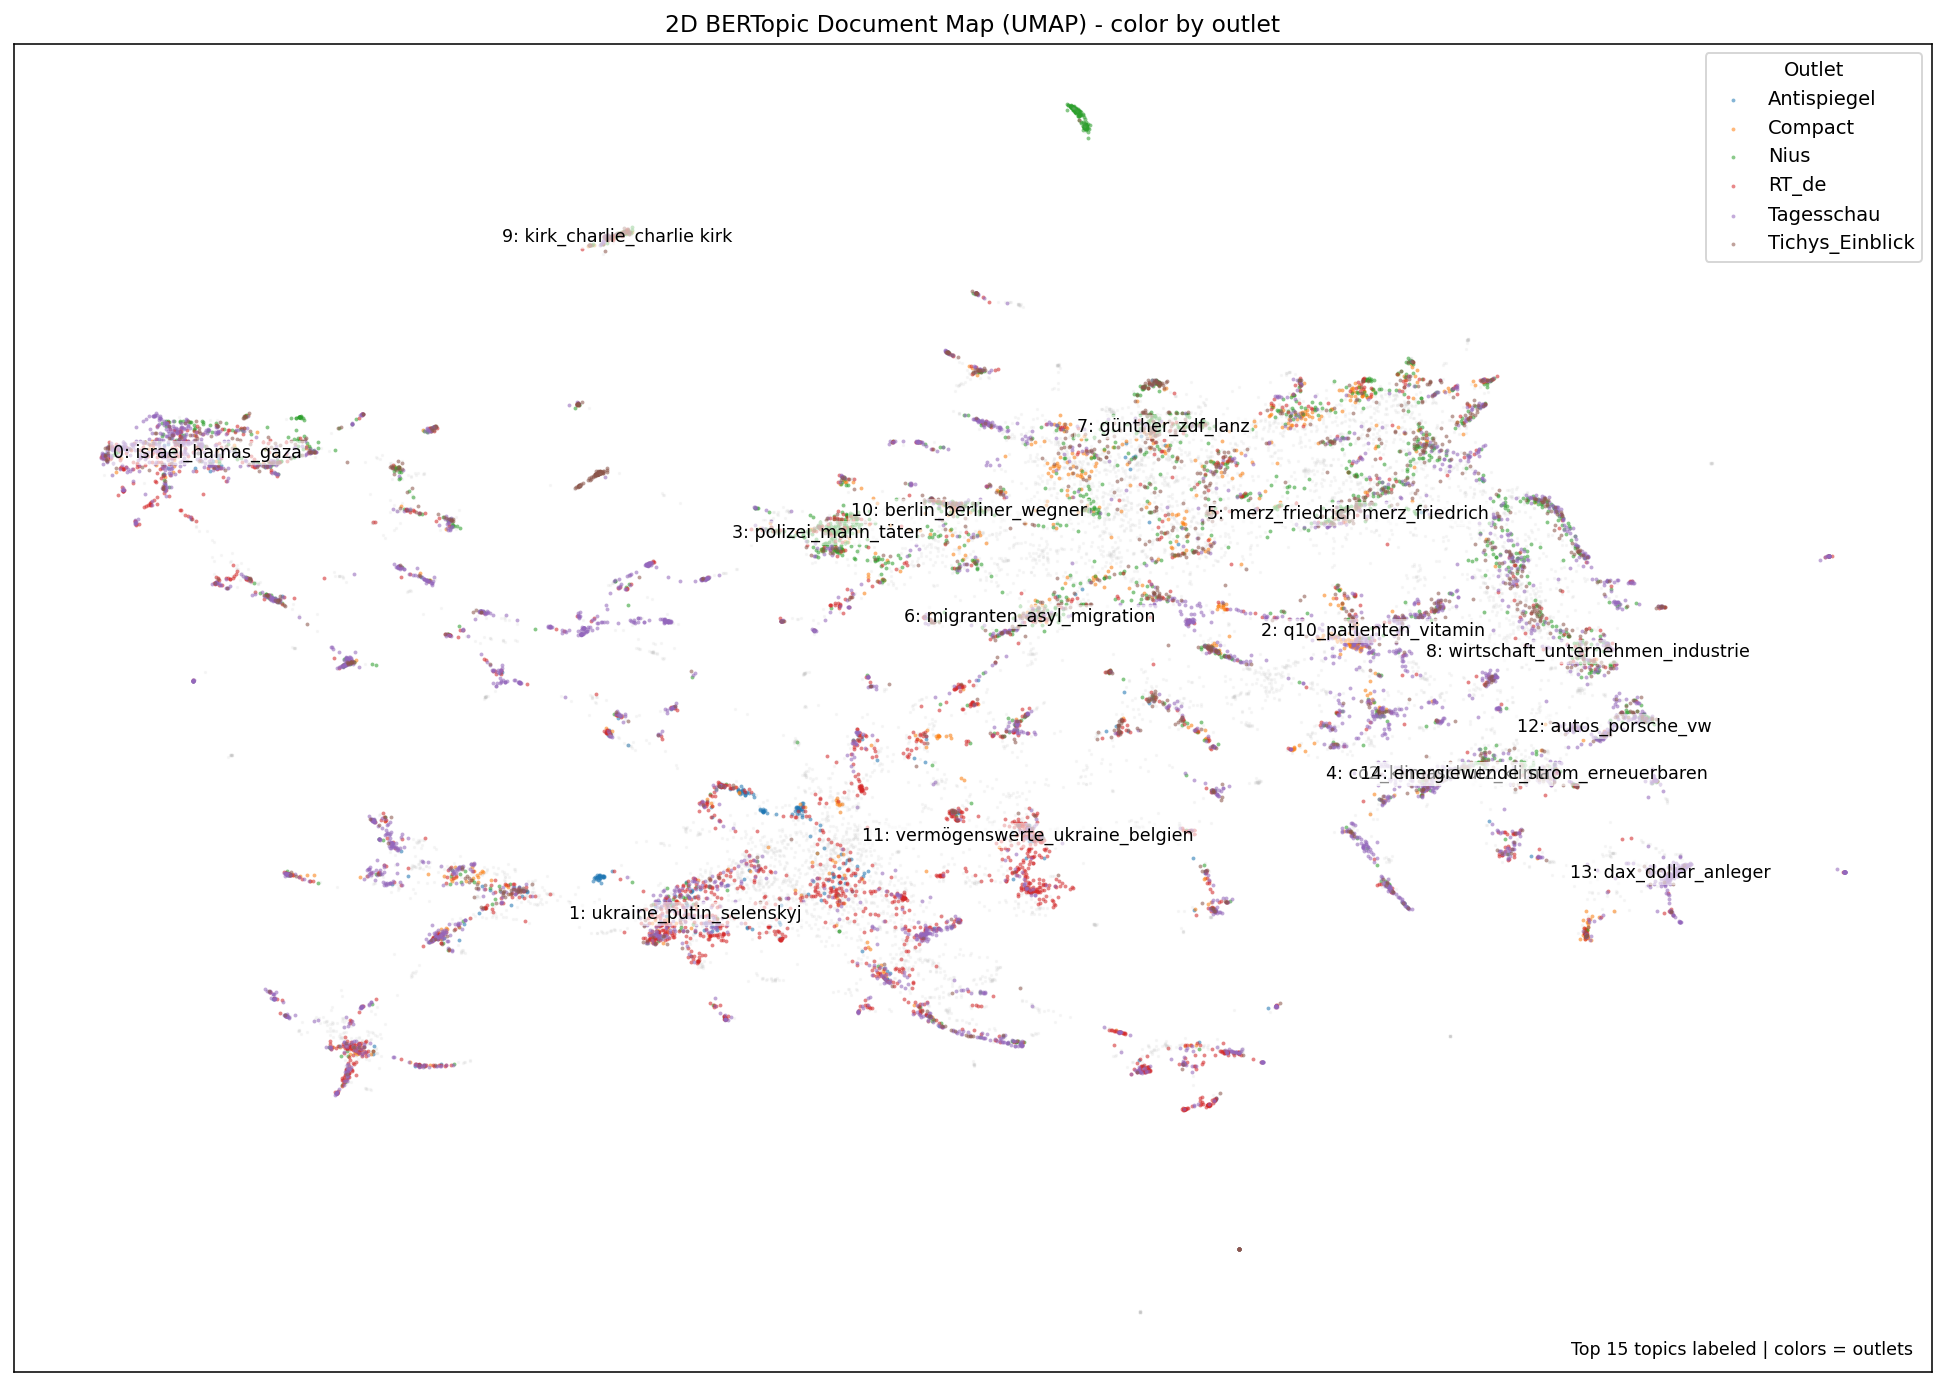

In [18]:
#2D document map: color by outlet, top-topic labels overlaid

import matplotlib.pyplot as plt

# Use model + docs/classes already created in earlier cells:
# topic_model, docs, classes

# 1) Get document embeddings from the fitted BERTopic embedding backend
embeddings = topic_model._extract_embeddings(docs, method="document")

# 2) Reduce to 2D (prefer UMAP; fallback to TSNE)
reducer_name = None
try:
    from BERTopic.bertopic_pipeline import _suppress_numba_cache_during_import
    with _suppress_numba_cache_during_import():
        from umap import UMAP
    reducer = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric="cosine", random_state=42)
    coords = reducer.fit_transform(embeddings)
    reducer_name = "UMAP"
except Exception as exc:
    from sklearn.manifold import TSNE
    print(f"UMAP unavailable ({exc}); falling back to TSNE.")
    reducer = TSNE(n_components=2, perplexity=30, init="pca", learning_rate="auto", random_state=42)
    coords = reducer.fit_transform(embeddings)
    reducer_name = "TSNE"

# 3) Build plotting dataframe
plot_df = pd.DataFrame(coords, columns=["x", "y"])
plot_df["topic"] = topic_model.topics_
plot_df["source"] = classes

inliers = plot_df[plot_df["topic"] != -1].copy()
outliers = plot_df[plot_df["topic"] == -1].copy()

# 4) Topic labels for top N non-outlier topics
top_n_topics = 15
top_topics = (
    topic_model.get_topic_freq()
    .query("Topic != -1")
    .head(top_n_topics)["Topic"]
    .tolist()
)
labels_df = inliers[inliers["topic"].isin(top_topics)].copy()

# 5) Plot: grey background + color by outlet
source_order = sorted(inliers["source"].unique().tolist())
palette = plt.get_cmap("tab10")
source_colors = {src: palette(i % 10) for i, src in enumerate(source_order)}

fig, ax = plt.subplots(figsize=(14, 10), dpi=140)

# Background points (all docs) in light grey for structure
ax.scatter(plot_df["x"], plot_df["y"], c="#E0E0E0", s=3, alpha=0.18, linewidths=0)

# Overlay non-outlier docs by outlet color
for src in source_order:
    subset = inliers[inliers["source"] == src]
    ax.scatter(
        subset["x"], subset["y"],
        s=4,
        alpha=0.55,
        color=source_colors[src],
        label=src,
        linewidths=0,
    )

# Optional: outliers even fainter
if len(outliers) > 0:
    ax.scatter(outliers["x"], outliers["y"], c="#BDBDBD", s=2, alpha=0.08, linewidths=0)

# 6) Add top-topic labels at centroids
centroids = labels_df.groupby("topic", as_index=False)[["x", "y"]].mean()
for _, row in centroids.iterrows():
    topic_id = int(row["topic"])
    words = topic_model.get_topic(topic_id)
    top_words = "_".join([w for w, _ in words[:3]]) if words else ""
    ax.text(
        row["x"], row["y"],
        f"{topic_id}: {top_words}",
        fontsize=9,
        ha="center",
        va="center",
        color="black",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.55, pad=1.5),
    )

ax.set_title(f"2D BERTopic Document Map ({reducer_name}) - color by outlet")
ax.text(
    0.99,
    0.01,
    f"Top {top_n_topics} topics labeled | colors = outlets",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
)
ax.set_xticks([])
ax.set_yticks([])
ax.legend(title="Outlet", loc="upper right", frameon=True)
plt.tight_layout()
plt.show()


## Actors prevalent

In [21]:
import plotly.express as px

target_forms = {
    "Trump": ["trump"],
    "Weidel": ["weidel"],
    "Merz": ["merz"],
    "Netanhjahu": ["netanhjahu", "netanjahu", "netanyahu"],
    "Putin": ["putin"],
    "Selenski": ["selenski", "selensky", "selenskyj", "selenskij", "zelensky", "zelenskyy"],
    "Scholz": ["scholz"],
    "Habeck": ["habeck"],
    "Baerbock": ["baerbock"],
    "Söder": ["söder", "soeder"],
    "Wagenknecht": ["wagenknecht"],
    "Höcke": ["höcke", "hoecke"],
    "Lindner": ["lindner"],
    "Klingbeil": ["klingbeil"],
    "Biden": ["biden"],
    "Macron": ["macron"],
    "Orban": ["orbán", "orban"],
    "Erdogan": ["erdoğan", "erdogan"],
    "von_der_leyen": ["leyen", "vonderleyen", "vdl"],  # multi-token name workaround
    "Kallas": ["kallas"],
    "Maduro": ["maduro"],}


form_to_target = {
    form: target
    for target, forms in target_forms.items()
    for form in forms
}

tokens = (
    overall_df[["source", "Title"]]
    .assign(token=lambda d: d["Title"].fillna("").str.casefold().str.findall(r"\b[\wäöüß-]+\b"))
    .explode("token")
    .dropna(subset=["token"])
)

counts = (
    tokens[tokens["token"].isin(form_to_target)]
    .assign(Target=lambda d: d["token"].map(form_to_target))
    .groupby(["source", "Target"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=target_forms.keys(), fill_value=0)
    .sort_index()
)

# Denominator: number of non-empty titles per outlet
titles_per_outlet = (
    overall_df.assign(has_title=overall_df["Title"].fillna("").str.strip().ne(""))
    .groupby("source")["has_title"]
    .sum()
    .reindex(counts.index)
)

relative = counts.div(titles_per_outlet, axis=0).fillna(0) * 100  # percent of titles

display(relative.style.format("{:.2f}%"))

fig = px.imshow(
    relative,
    text_auto=".2f",
    color_continuous_scale="Blues",
    labels={"x": "Target", "y": "Outlet", "color": "% of titles"},
    title="Target word mentions in Title relative to number of titles per outlet (%)",
)
fig.update_traces(
    customdata=counts.to_numpy(),
    hovertemplate=(
        "Outlet: %{y}<br>"
        "Target: %{x}<br>"
        "Share of titles: %{z:.2f}%<br>"
        "Absolute count: %{customdata}<extra></extra>"
    ),
)
fig.show()


Target,Trump,Weidel,Merz,Netanhjahu,Putin,Selenski,Scholz,Habeck,Baerbock,Söder,Wagenknecht,Höcke,Lindner,Klingbeil,Biden,Macron,Orban,Erdogan,von_der_leyen,Kallas,Maduro,Lügenpresse,Systempresse,Lügenmedien,Lügenjournalismus,Lügenpropaganda,Lügenpressejournalismus,Lügenpressepropaganda
source,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Antispiegel,6.45%,0.00%,1.87%,0.68%,3.74%,3.23%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.17%,0.68%,0.00%,0.51%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
Compact,2.62%,0.83%,3.13%,0.19%,1.21%,0.19%,0.00%,0.19%,0.00%,0.06%,0.38%,0.58%,0.00%,0.00%,0.00%,0.19%,0.19%,0.00%,0.13%,0.06%,0.13%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
Nius,2.29%,0.37%,7.25%,0.24%,0.40%,0.28%,0.03%,0.28%,0.18%,0.76%,0.21%,0.09%,0.00%,0.89%,0.03%,0.12%,0.12%,0.03%,0.18%,0.03%,0.24%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
RT_de,7.48%,0.26%,1.69%,0.59%,3.36%,2.81%,0.04%,0.15%,0.02%,0.15%,0.13%,0.02%,0.04%,0.15%,0.07%,0.92%,0.77%,0.15%,0.68%,0.42%,0.75%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
Tagesschau,4.05%,0.02%,1.09%,0.30%,0.84%,1.04%,0.00%,0.03%,0.05%,0.17%,0.09%,0.02%,0.02%,0.30%,0.00%,0.19%,0.08%,0.02%,0.09%,0.05%,0.14%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
Tichys_Einblick,2.99%,0.10%,6.11%,0.03%,0.61%,0.44%,0.03%,0.37%,0.07%,0.20%,0.10%,0.00%,0.07%,0.88%,0.00%,0.37%,0.37%,0.00%,0.78%,0.03%,0.10%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
